# <h1 style="font-family: Trebuchet MS; padding: 20px; font-size: 25px; color: #2D2926; text-align: center; line-height: 0.75;background-color: #FF781F"><b>Unsupervised Learning : Allocation des fonds aux pays dans le besoin</b><br></h1>

## <center> Énoncé du problème :</center>

Médecins Sans Frontières (MSF) est une ONG humanitaire internationale engagée dans la lutte contre la pauvreté et la fourniture d’aides essentielles aux populations des pays défavorisés, notamment en période de catastrophes et de calamités naturelles. L’organisation a réussi à collecter environ 10 millions de dollars. Ces fonds doivent désormais être alloués de manière stratégique et efficace.

## <center>Travail A Faire (TAF)</center>
Le Directeur Général de MSF doit maintenant décider comment utiliser cet argent de manière stratégique et efficace. Il doit donc prendre des décisions pour sélectionner les pays qui ont le plus urgent besoin d’aide.

Votre rôle, en tant que data scientist, est de catégoriser les pays en utilisant certains facteurs socio-économiques et sanitaires qui déterminent le niveau global de développement d’un pays. Ensuite, vous devrez proposer les pays sur lesquels le Directeur Général devra concentrer prioritairement les efforts.

## <center>Objectif :</center>

* Regrouper les pays en classes à partir de variables numériques.

* Il s’agit d’un problème d’apprentissage non supervisé.


##<center>Attributs du jeu de données</center>

* **country** : Nom du pays

* **child_mort** : Nombre de décès d’enfants de moins de 5 ans pour 1000 naissances vivantes

* **exports** : Exportations de biens et services par habitant, exprimées en pourcentage du PIB par habitant

* **health** : Dépenses de santé totales par habitant, exprimées en pourcentage du PIB par habitant

* **imports** : Importations de biens et services par habitant, exprimées en pourcentage du PIB par habitant

* **Income** : Revenu net par personne

* **Inflation** : Augmentation du niveau general des prix

* **life_expec** : Espérance de vie moyenne à la naissance, si les tendances actuelles de mortalité se maintiennent

* **total_fer** : Nombre moyen d’enfants qu’aurait chaque femme si les taux de fécondité actuels par âge restaient constants

* **gdpp** : PIB par habitant, calculé comme le PIB total divisé par la population totale

## Ce que vous allez apprendre :

* Les techniques de visualisation de données.

* L’ACP (Analyse en Composantes Principales).

* Le Clustering K-Means.

**Ce qui nous interesse**
Les pays les plus pauvres

# <center><div style="font-family: Trebuchet MS; background-color: #FF781F; color: #2D2926; padding: 12px; line-height: 1;">Dataset Information</div></center>

### Import the Necessary Libraries :

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

import plotly.express as px
!pip install -U kaleido
import kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 3.3 MB/s eta 0:00:00


In [3]:
# Télécharger le fichier CSV directement depuis GitHub
!wget https://raw.githubusercontent.com/bidoscar/AFRICITIZEN-ACDS-Coding/main/Seance_8_Clustering_PCA/datasets/Country-data.csv

--2025-09-23 18:45:06--  https://raw.githubusercontent.com/bidoscar/AFRICITIZEN-ACDS-Coding/main/Seance_8_Clustering_PCA/datasets/Country-data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9061 (8.8K) [text/plain]
Saving to: ‘Country-data.csv’

Country-data.csv    100%[===================>]   8.85K  --.-KB/s    in 0s      

2025-09-23 18:45:07 (59.1 MB/s) - ‘Country-data.csv’ saved [9061/9061]



In [4]:
data = pd.read_csv('Country-data.csv')
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


### Data Info :

In [5]:
data.shape

(167, 10)

In [6]:
data.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.00,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.00,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.00,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.00,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.00,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.00,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.00,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.00,2.95,1.51,1.15,1.79,2.41,3.88,7.49
gdpp,167.00,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


Verifier les valeurs manquantes

In [9]:
data.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


# <center><div style="font-family: Trebuchet MS; background-color: #FF781F; color: #2D2926; padding: 12px; line-height: 1;">Exploratory Data Analysis</div></center>

In [10]:
cat_var = data.select_dtypes(include='object').columns
cat_var

Index(['country'], dtype='object')

In [11]:
num_var = data.select_dtypes(exclude='object').columns
num_var

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

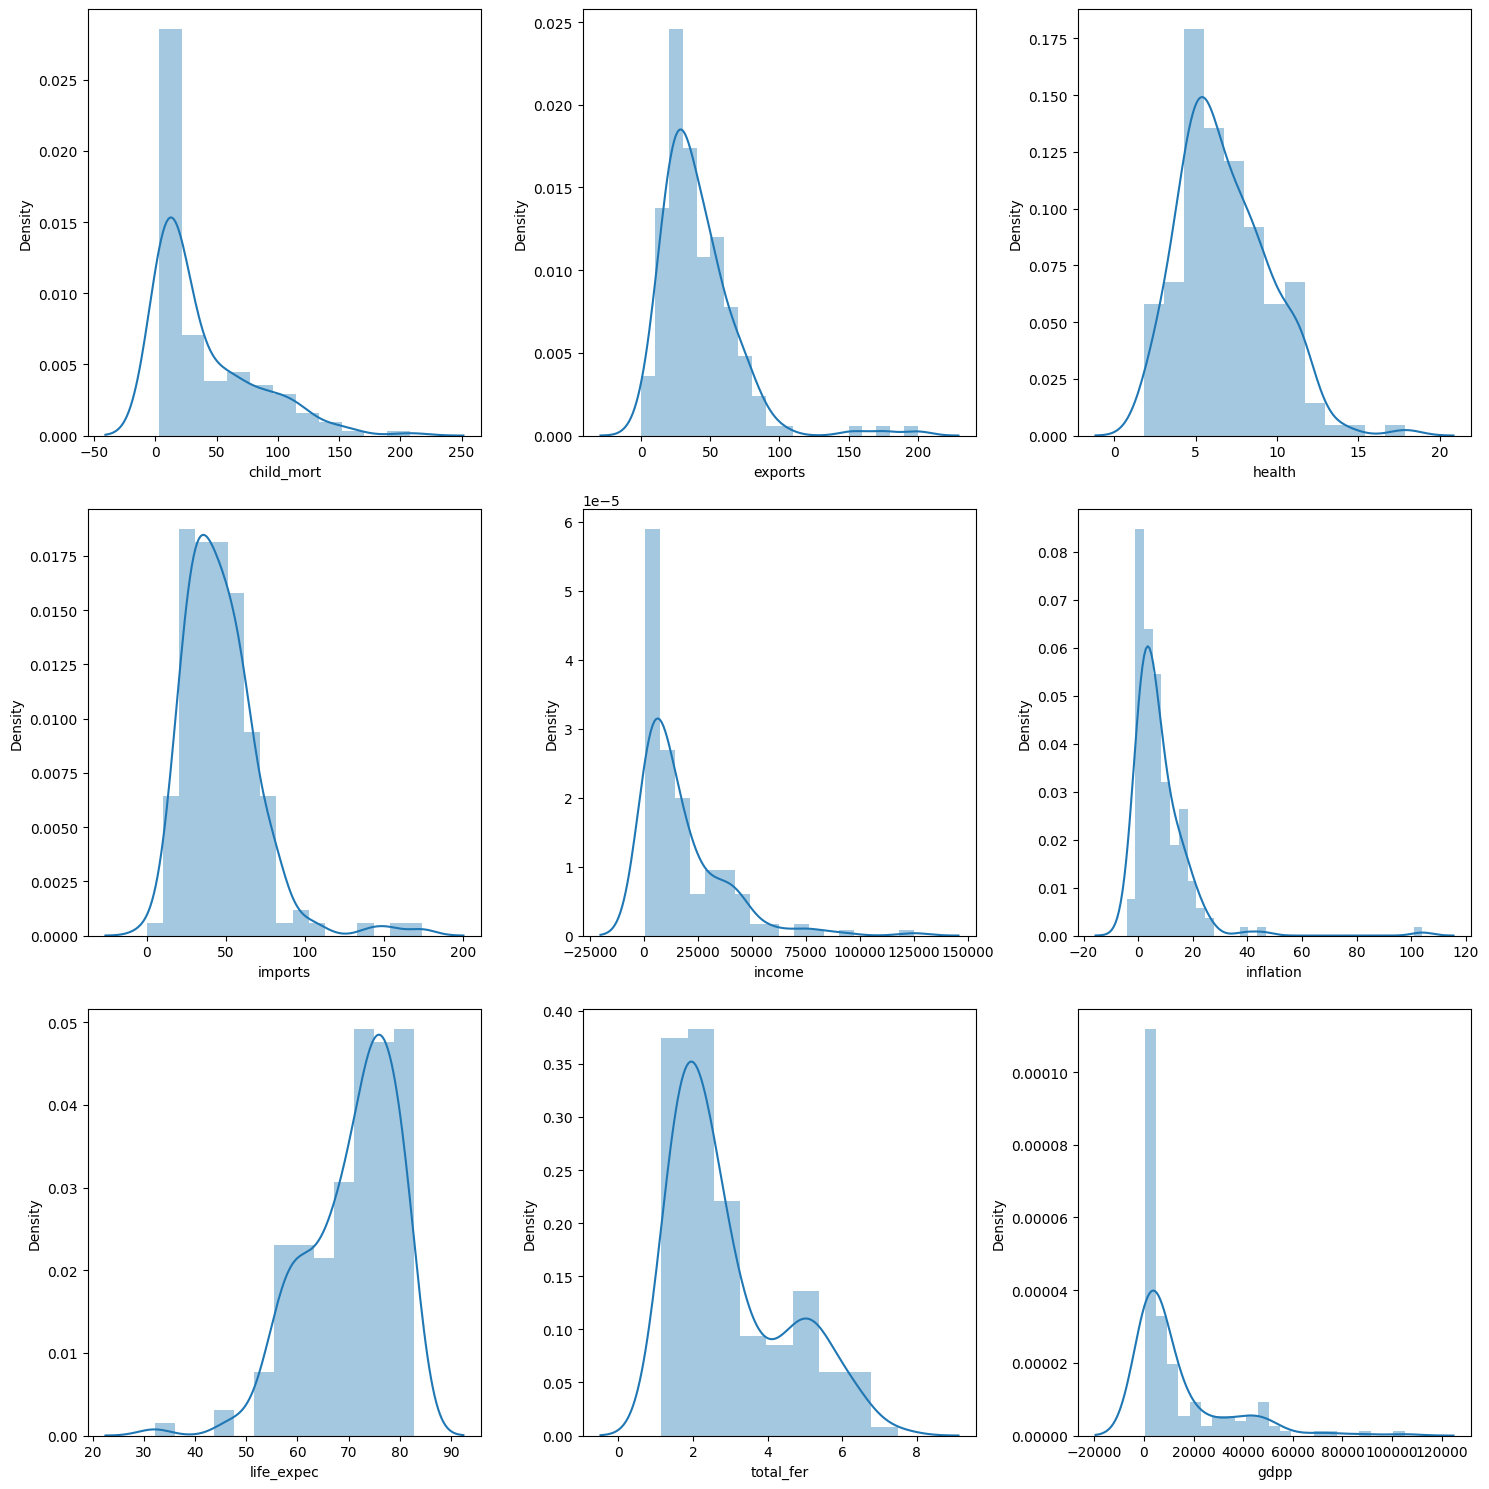

In [12]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
for i in range(len(num_var)):
    sns.distplot(data[num_var[i]], ax=ax[i//3, i%3])
plt.tight_layout()
plt.show()


In [13]:
# Verifier les doublons
data.duplicated().sum() # ce n'est la meilleure approche

np.int64(0)

In [14]:
len(data['country'].unique()) == data.shape[0] # Pas de doublons

True

### Distribution of Features :

In [15]:
data.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

### Caractéristiques des pays défavorisés :

* **child_mort** : Eleve
* **exports** : Faible
* **health** : Faible
* **imports** : Eleve
* **income** : Faible
* **inflation** : Eleve
* **life_expec** : Faible
* **total_fer** : Eleve
* **gdpp** : Faible

### country vs Numerical Features :

In [16]:
data.sort_values(by='child_mort', ascending=False).head(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
66,Haiti,208.00,15.30,6.91,64.70,1500,5.45,32.10,3.33,662
132,Sierra Leone,160.00,16.80,13.10,34.50,1220,17.20,55.00,5.20,399
32,Chad,150.00,36.80,4.53,43.50,1930,6.39,56.50,6.59,897
31,Central African Republic,149.00,11.80,3.98,26.50,888,2.01,47.50,5.21,446
97,Mali,137.00,22.80,4.98,35.10,1870,4.37,59.50,6.55,708


In [17]:
data.sort_values(by='child_mort', ascending=False).tail(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
53,Finland,3.00,38.70,8.95,37.40,39800,0.35,80.00,1.87,46200
144,Sweden,3.00,46.20,9.63,40.70,42900,0.99,81.50,1.98,52100
91,Luxembourg,2.80,175.00,7.77,142.00,91700,3.62,81.30,1.63,105000
133,Singapore,2.80,200.00,3.96,174.00,72100,-0.05,82.70,1.15,46600
68,Iceland,2.60,53.40,9.40,43.30,38800,5.47,82.00,2.20,41900


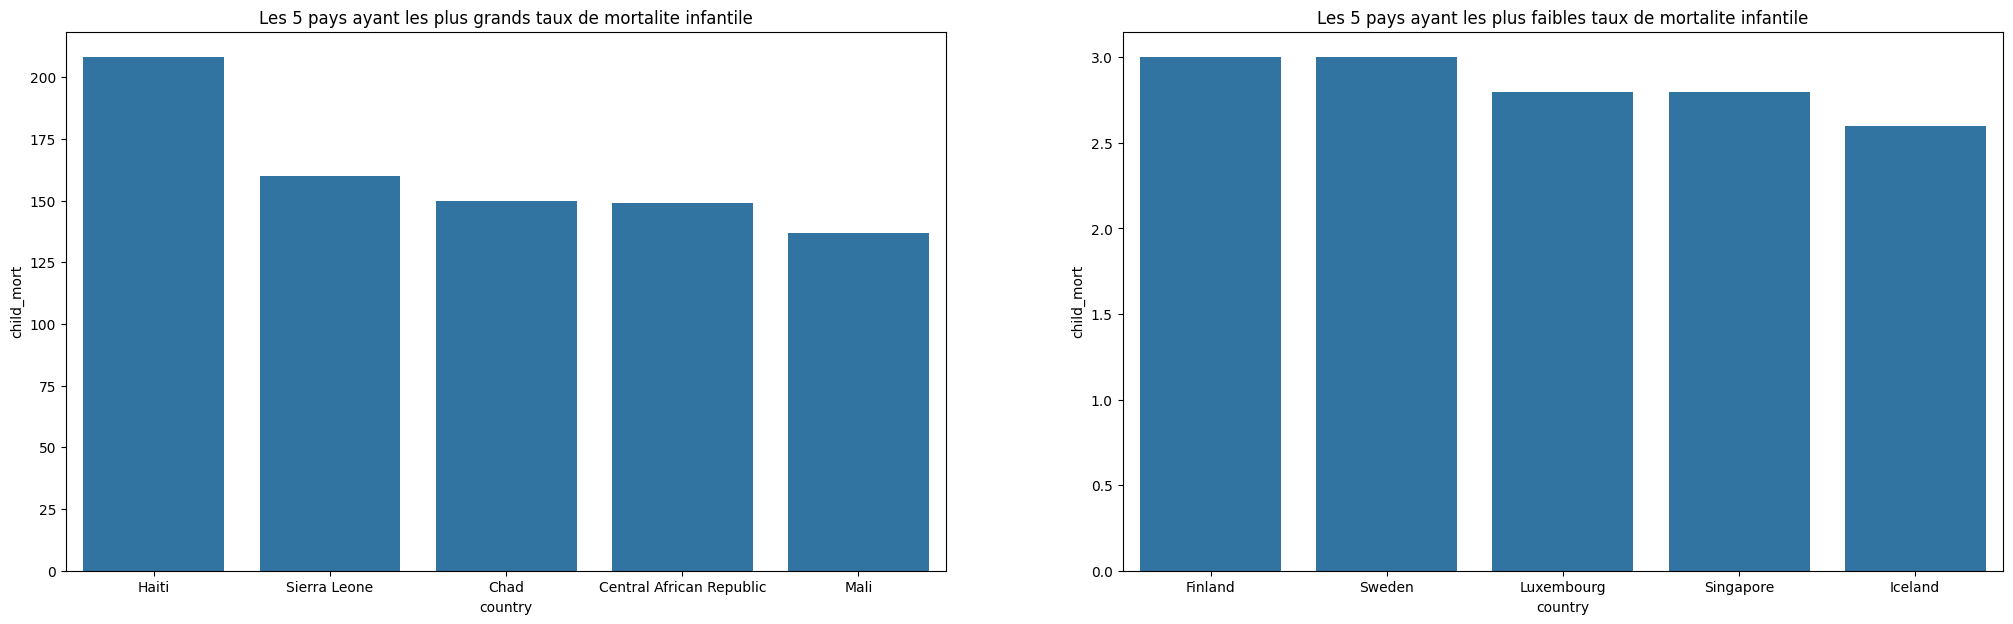

In [20]:
# Faire le graphique des 5 pays ayant le taux de mortalite infantile le plus
fig = plt.subplots(nrows = 1, ncols = 2, figsize=(25, 7))
plt.subplot(1, 2, 1)
ax = sns.barplot(x = "country", y="child_mort", data = data.sort_values(by='child_mort', ascending=False).head(5))
plt.title("Les 5 pays ayant les plus grands taux de mortalite infantile")

plt.subplot(1, 2, 2)
ax = sns.barplot(x = "country", y="child_mort", data = data.sort_values(by='child_mort', ascending=False).tail(5))
plt.title("Les 5 pays ayant les plus faibles taux de mortalite infantile")

plt.show()

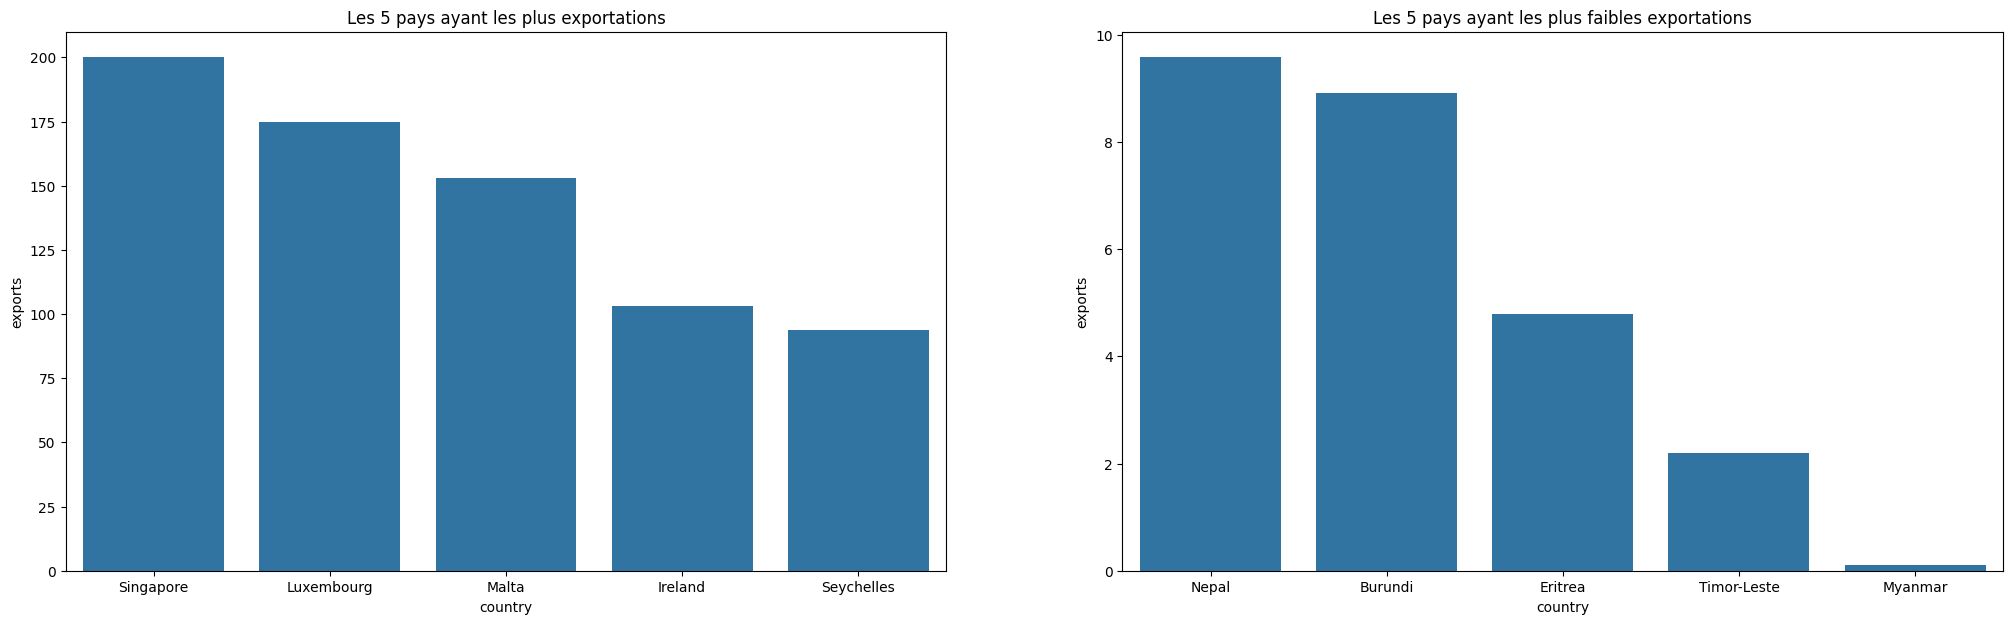

In [21]:
# Faire le graphique des exportations
fig = plt.subplots(nrows = 1, ncols = 2, figsize=(25, 7))
plt.subplot(1, 2, 1)
ax = sns.barplot(x = "country", y="exports", data = data.sort_values(by='exports', ascending=False).head(5))
plt.title("Les 5 pays ayant les plus exportations")

plt.subplot(1, 2, 2)
ax = sns.barplot(x = "country", y="exports", data = data.sort_values(by='exports', ascending=False).tail(5))
plt.title("Les 5 pays ayant les plus faibles exportations")

plt.show()

###  Numerical Features :

# <center><div style="font-family: Trebuchet MS; background-color: #FF781F; color: #2D2926; padding: 12px; line-height: 1;">Summary EDA</div></center>

# <center><div style="font-family: Trebuchet MS; background-color: #FF781F; color: #2D2926; padding: 12px; line-height: 1;">Feature Engineering</div></center>

### Correlation Matrix :

<Axes: >

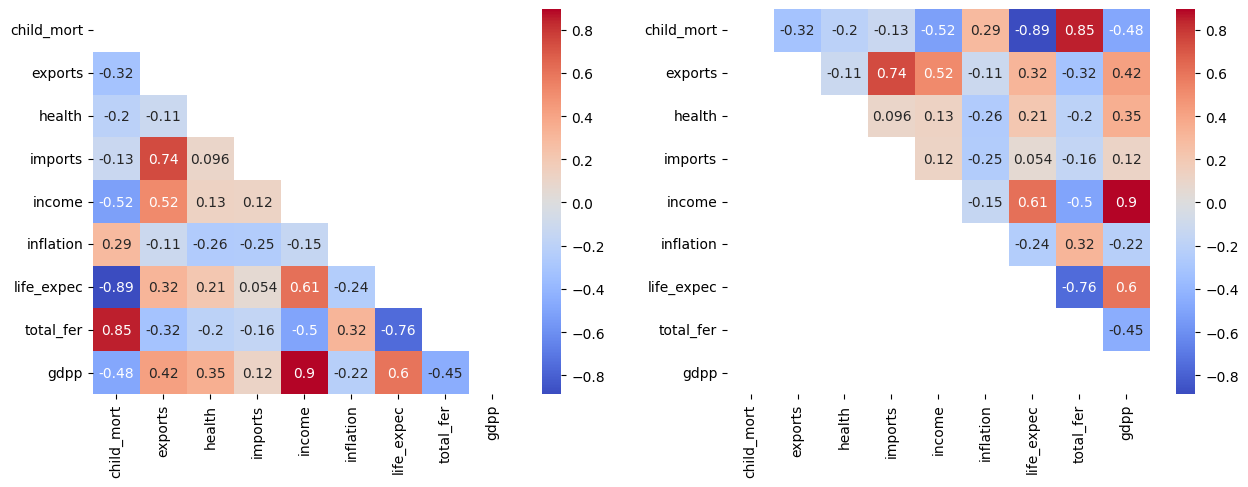

In [25]:
ut = np.triu(data.drop(columns='country').corr())
lt = np.tril(data.drop(columns='country').corr())

list_col = data.drop(columns='country').columns

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
sns.heatmap(lt, annot=True, cmap='coolwarm', mask=ut, cbar=True, xticklabels=list_col, yticklabels=list_col, ax=ax[0])
sns.heatmap(ut, annot=True, cmap='coolwarm', mask=lt, cbar=True, xticklabels=list_col, yticklabels=list_col, ax=ax[1])

### Data Scaling :

In [26]:
# Faire la normalisation en utilisant MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data.drop(columns='country'))
data_scaled = pd.DataFrame(data_scaled, columns=data.drop(columns='country').columns)
data_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.43,0.05,0.36,0.26,0.01,0.13,0.48,0.74,0.00
1,0.07,0.14,0.29,0.28,0.07,0.08,0.87,0.08,0.04
2,0.12,0.19,0.15,0.18,0.10,0.19,0.88,0.27,0.04
3,0.57,0.31,0.06,0.25,0.04,0.25,0.55,0.79,0.03
4,0.04,0.23,0.26,0.34,0.15,0.05,0.88,0.15,0.11


In [27]:
data_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.00,0.17,0.20,0.00,0.03,0.08,0.29,1.00
exports,167.00,0.21,0.14,0.00,0.12,0.17,0.26,1.00
health,167.00,0.31,0.17,0.00,0.19,0.28,0.42,1.00
imports,167.00,0.27,0.14,0.00,0.17,0.25,0.34,1.00
income,167.00,0.13,0.15,0.00,0.02,0.08,0.18,1.00
inflation,167.00,0.11,0.10,0.00,0.06,0.09,0.14,1.00
life_expec,167.00,0.76,0.18,0.00,0.65,0.81,0.88,1.00
total_fer,167.00,0.28,0.24,0.00,0.10,0.20,0.43,1.00
gdpp,167.00,0.12,0.17,0.00,0.01,0.04,0.13,1.00


## <center>K-Means Clustering</center>

**K-Means Clustering** est un algorithme basé sur la distance utilisé en apprentissage non supervisé qui **ne prend pas en charge les variables catégorielles**.

* C’est l’algorithme le plus couramment utilisé pour traiter l’**apprentissage non supervisé**, avec une approche mathématique permettant de trouver des clusters dans les données :

  * Sélection aléatoire de 2 centroïdes (supposons k = 2).
  * Calcul de la distance entre les centroïdes et tous les points de données.
  * Si un point est plus proche d’un centroïde, il est alors attribué à ce cluster, et vice versa.
  * Pour les 2 clusters formés, on calcule la valeur moyenne des points regroupés autour de chaque centroïde, et ces moyennes deviennent les nouveaux centroïdes.
  * Le processus se répète jusqu’à ce que les centroïdes convergent vers des positions fixes.

* **Hyperparamètre k** : Il définit le nombre de clusters ou groupes dans lesquels les données doivent être réparties. Pour sélectionner la valeur optimale de **k**, on utilise deux méthodes statistiques :

  * **Méthode du coude (Elbow Method)** : Elle trace la somme des erreurs quadratiques pour différentes valeurs de **k**. Lorsque la courbe prend la forme d’un bras, la valeur de **k** correspondant au **coude** est choisie. À partir de ce point, la somme des carrés (inertie) diminue de façon linéaire et cette valeur est donc considérée comme optimale.
  * **Méthode du score de silhouette (Silhouette Score)** : Elle évalue la qualité des clusters en mesurant à quel point les points sont bien regroupés avec d’autres points similaires. Ce score est calculé à l’aide d’une formule de distance, et la valeur de **k** qui maximise ce score est retenue pour le modèle.

#### Elbow Method & Silhouette Score Method :

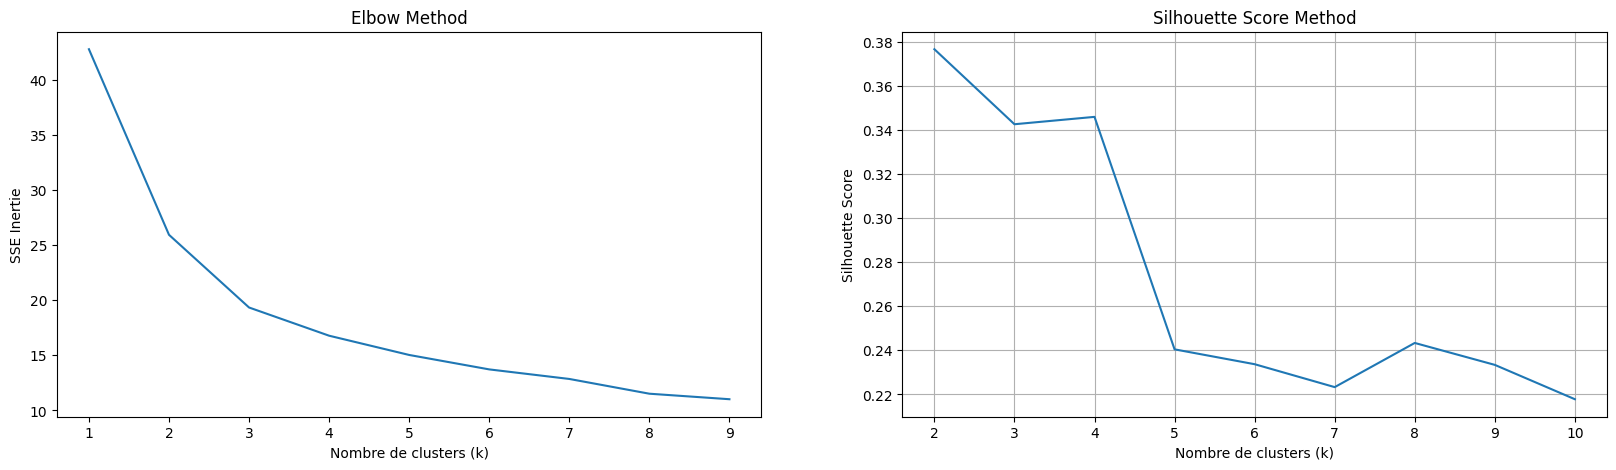

In [31]:
sse = {}; sil = []; kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize=(20, 5))

# Elbow Method
plt.subplot(1, 2, 1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000,random_state=0).fit(data_scaled)
    sse[k] = kmeans.inertia_
sns.lineplot(x = list(sse.keys()), y = list(sse.values()))
plt.title('Elbow Method')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("SSE Inertie")

# Silhouette Score Method
plt.subplot(1, 2, 2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, max_iter=1000,random_state=0).fit(data_scaled)
    label = kmeans.labels_
    sil.append(silhouette_score(data_scaled, label, metric='euclidean'))

sns.lineplot(x = list(range(2, kmax + 1)), y = sil)
plt.title('Silhouette Score Method')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid()

plt.show()

Nous prenons K = 3

In [32]:
# Faire le clustering avec 3 classes
kmeans = KMeans(n_clusters=3, max_iter=1000,random_state=0)
kmeans.fit(data_scaled)
cluster = kmeans.cluster_centers_
centroids = np.array(cluster)
labels = kmeans.labels_
data["Class"] = labels

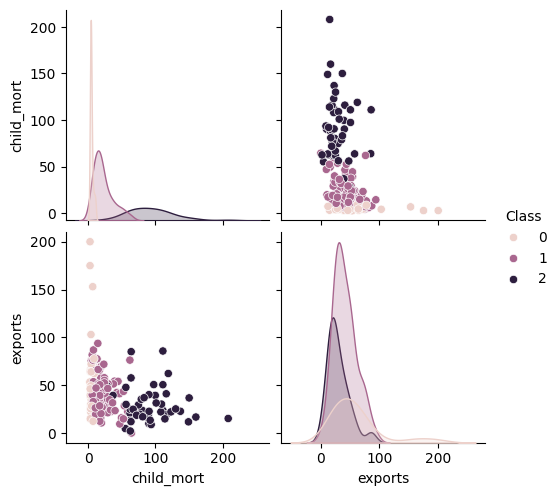

In [39]:
# Faire le pairplot sur data_scaled
sns.pairplot(data[['child_mort', 'exports', 'Class']], hue='Class')

In [34]:
data_scaled.columns

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

<Axes: xlabel='Class', ylabel='child_mort'>

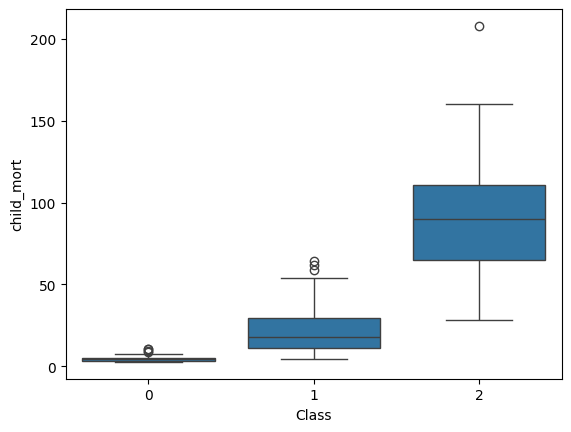

In [40]:
# Boxplot de child_mortality par class
sns.boxplot(x='Class', y='child_mort', data=data)

<Axes: xlabel='Class', ylabel='income'>

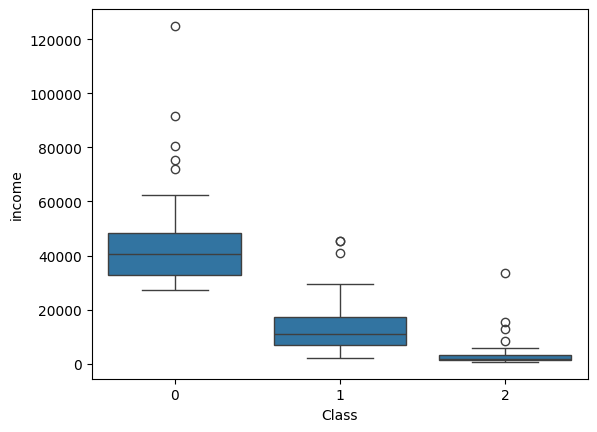

In [41]:
# Boxplot de child_mortality par class
sns.boxplot(x='Class', y='income', data=data)

<Axes: xlabel='Class', ylabel='inflation'>

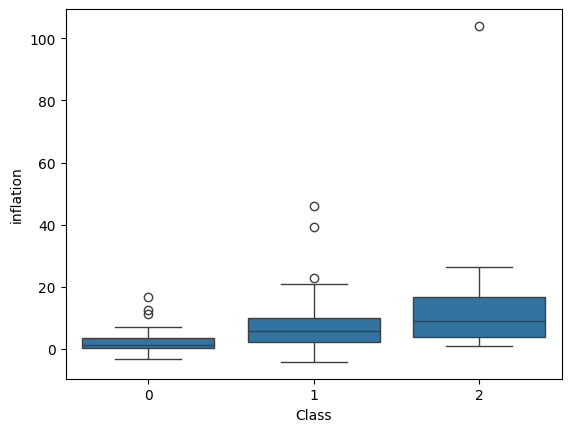

In [42]:
# Boxplot de child_mortality par class
sns.boxplot(x='Class', y='inflation', data=data)

Au vue des boxplots, on peut dire que:

* 0 : Pas besoin d'aide
* 1 : Pourrait avoir besoin d'aide
* 2 : Besoin d'aide

In [43]:
mapping = {
    0: 'Pas besoin d\'aide',
    1: 'Pourrait avoir besoin d\'aide',
    2: 'Besoin d\'aide'}
data['Class'] = data['Class'].map(mapping)

In [44]:
data['Class'].value_counts()

,count
Class,
Pourrait avoir besoin d'aide,87
Besoin d'aide,46
Pas besoin d'aide,34


In [48]:
fig = px.choropleth(data[['country', 'Class']],
                    locationmode= 'country names',
                    locations= 'country',
                    color = data['Class'],
                    title = 'Pays selon leur besoin d\'aide',
                    color_discrete_map= {
                        'Pas besoin d\'aide': 'green',
                        'Pourrait avoir besoin d\'aide': 'yellow',
                        'Besoin d\'aide': 'red'
                    })

fig.update_geos(fitbounds = "locations", visible = True)
fig.update_layout(legend_title_text = 'Labels', legend_title_side = 'top')
fig.show()

### Principal Component Analysis (PCA) :

- It is a dimension reduction method that is preferrably used for an Unsupervised Learning Problem.

## 🌍 1. Idée intuitive

Imaginez un tableau avec **beaucoup de variables** (revenu, mortalité infantile, PIB, inflation, etc.).
Certaines de ces variables se ressemblent :

* `PIB` et `revenu` → très corrélés
* `mortalité infantile` et `espérance de vie` → fortement liés aussi

👉 Donc le jeu de données contient **de l’information redondante**.

La PCA sert à :

* **Compresser** ces variables en **nouvelles dimensions** (appelées composantes principales).
* Garder **l’essentiel de l’information** (la variance) avec moins de variables.
* Éliminer les corrélations et redondances.

---

## 🔢 2. Comment ça marche ?

1. **Standardiser** les données (mettre toutes les variables sur la même échelle).
2. **Calculer la matrice de covariance** pour voir comment les variables varient ensemble.
3. **Trouver les valeurs propres (eigenvalues) et vecteurs propres (eigenvectors)** :

   * Chaque vecteur propre = une **composante principale (PC1, PC2, …)**.
   * Chaque valeur propre = la **part de variance expliquée** par cette composante.
4. **Projeter les données** dans ce nouvel espace → on obtient de nouvelles coordonnées (`PC1`, `PC2`, …).

- Before passing the data for PCA transformation, **normalization** & **standardization** are very important.

## Clustering after PCA

# **Comparer les deux methodes**